In [1]:
# 1: Imports & basic setup

import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


In [2]:
# 2: Mount Google Drive & define paths

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

PROJECT_ROOT = Path("/content/drive/MyDrive/mbti-tune")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_PLAYLIST_DIR = DATA_DIR / "raw" / "raw_playlists"
MBTI_PLAYLIST_DIR = DATA_DIR / "raw" / "mbti_playlists"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_PLAYLIST_DIR:", RAW_PLAYLIST_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/mbti-tune
RAW_PLAYLIST_DIR: /content/drive/MyDrive/mbti-tune/data/raw/raw_playlists
PROCESSED_DIR: /content/drive/MyDrive/mbti-tune/data/processed


In [3]:
import pandas as pd
import numpy as np
from collections import Counter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("Parsing raw_playlists into song-level dataset")
print("="*60)

# Define STANDARD audio features - INSTRUMENTALNESS REMOVED
STANDARD_AUDIO_FEATURES = [
    'danceability', 'energy', 'valence', 'acousticness',
    # 'instrumentalness',  # REMOVED - 95% zeros, causes severe bias (ESTP +310%, INTP -98%)
    'speechiness', 'loudness', 'tempo', 'liveness'
]

# Optional: include popularity if available
OPTIONAL_FEATURES = ['popularity']

print(f"Standard audio features: {len(STANDARD_AUDIO_FEATURES)}")
print(f"Features: {STANDARD_AUDIO_FEATURES}")
print(f"\n⚠️ Note: 'instrumentalness' REMOVED due to 95% zero values causing prediction bias")

# Mapping from raw_playlists column names to standard names
RAW_COLUMN_MAPPING = {
    'Dance': 'danceability',
    'Energy': 'energy',
    'Valence': 'valence',
    'Acoustic': 'acousticness',
    'Instrumental': 'instrumentalness',  # Will be mapped but not used
    'Speech': 'speechiness',
    'Loud (Db)': 'loudness',
    'BPM': 'tempo',
    'Live': 'liveness',
    'Popularity': 'popularity',
    'Key': 'key'
}

# Parse all playlists
all_songs = []
duplicate_count = 0
error_count = 0
mbti_counts = Counter()
folder_counts = {}

RAW_PLAYLIST_PATH = Path("/content/drive/MyDrive/mbti-tune/data/raw/raw_playlists")

if not RAW_PLAYLIST_PATH.exists():
    print(f"❌ Path not found: {RAW_PLAYLIST_PATH}")
else:
    print(f"✅ Found raw_playlists at: {RAW_PLAYLIST_PATH}")

for mbti_folder in sorted(RAW_PLAYLIST_PATH.iterdir()):
    if not mbti_folder.is_dir():
        continue

    mbti_type = mbti_folder.name
    folder_counts[mbti_type] = 0
    song_ids_in_this_mbti = set()

    csv_files = list(mbti_folder.glob("*.csv"))
    print(f"\n📁 Processing {mbti_type}: {len(csv_files)} CSV files")

    for csv_file in csv_files:
        try:
            # Try different encodings
            df = None
            for encoding in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    df = pd.read_csv(csv_file, encoding=encoding, on_bad_lines='skip')
                    break
                except:
                    continue

            if df is None:
                print(f"   ⚠️ Could not read {csv_file.name}")
                continue

            folder_counts[mbti_type] += 1

            # Rename columns to standard names
            df = df.rename(columns=RAW_COLUMN_MAPPING)

            for idx, row in df.iterrows():
                # Create unique identifier
                artist = str(row.get('Artist', 'unknown'))[:50]
                song = str(row.get('Song', 'unknown'))[:50]
                song_id = f"{artist}_{song}"

                # Check duplicates within same MBTI
                if song_id in song_ids_in_this_mbti:
                    duplicate_count += 1
                    continue

                song_ids_in_this_mbti.add(song_id)

                # Extract features (skip instrumentalness)
                song_data = {'mbti': mbti_type}
                for feature in STANDARD_AUDIO_FEATURES:
                    value = row.get(feature, 0)
                    try:
                        # Handle percentage values (e.g., "58" means 0.58)
                        if isinstance(value, (int, float)) and feature not in ['loudness', 'tempo']:
                            if value > 1 and value <= 100:
                                value = value / 100.0
                        song_data[feature] = float(value)
                    except (ValueError, TypeError):
                        song_data[feature] = 0.0

                all_songs.append(song_data)
                mbti_counts[mbti_type] += 1

        except Exception as e:
            error_count += 1
            if error_count <= 10:
                print(f"   ❌ Error: {csv_file.name[:50]} - {str(e)[:50]}")
            continue

# Create DataFrame
if all_songs:
    song_df = pd.DataFrame(all_songs)
    print(f"\n✅ Parsed {len(song_df):,} unique songs from {sum(folder_counts.values())} playlist files")
    print(f"   Duplicates skipped: {duplicate_count}")
    print(f"   Errors encountered: {error_count}")

    print(f"\n📊 MBTI Distribution in song dataset:")
    for mbti, count in sorted(mbti_counts.items(), key=lambda x: x[1], reverse=True):
        bar_length = int(count / 300)
        bar = "█" * min(bar_length, 40)
        print(f"   {mbti}: {count:6,} songs {bar}")

    # Verify features
    print(f"\n✅ Standard features available in song_df:")
    for feat in STANDARD_AUDIO_FEATURES:
        if feat in song_df.columns:
            non_zero = (song_df[feat] != 0).sum()
            min_val = song_df[feat].min()
            max_val = song_df[feat].max()
            print(f"   ✅ {feat:15} : range [{min_val:.3f}, {max_val:.3f}], {non_zero:,} non-zero")
        else:
            print(f"   ❌ {feat}: MISSING!")

    # Show sample
    print(f"\n📝 Sample songs (first 5):")
    print(song_df[['mbti'] + STANDARD_AUDIO_FEATURES[:5]].head())

    # Ensure PROCESSED_DIR exists before saving
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

    # Save processed song data
    song_df.to_csv(PROCESSED_DIR / "processed_songs.csv", index=False)
    print(f"\n✅ Saved processed songs to {PROCESSED_DIR / 'processed_songs.csv'}")

else:
    print("\n❌ No songs were successfully parsed!")

Parsing raw_playlists into song-level dataset
Standard audio features: 8
Features: ['danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'loudness', 'tempo', 'liveness']

⚠️ Note: 'instrumentalness' REMOVED due to 95% zero values causing prediction bias
✅ Found raw_playlists at: /content/drive/MyDrive/mbti-tune/data/raw/raw_playlists

📁 Processing ENFJ: 20 CSV files

📁 Processing ENFP: 20 CSV files

📁 Processing ENTJ: 20 CSV files

📁 Processing ENTP: 20 CSV files

📁 Processing ESFJ: 20 CSV files

📁 Processing ESFP: 20 CSV files

📁 Processing ESTJ: 22 CSV files

📁 Processing ESTP: 20 CSV files

📁 Processing INFJ: 20 CSV files

📁 Processing INFP: 20 CSV files

📁 Processing INTJ: 20 CSV files

📁 Processing INTP: 20 CSV files

📁 Processing ISFJ: 20 CSV files

📁 Processing ISFP: 20 CSV files

📁 Processing ISTJ: 20 CSV files

📁 Processing ISTP: 24 CSV files

✅ Parsed 44,310 unique songs from 326 playlist files
   Duplicates skipped: 10033
   Errors encountered: 0

📊 MBTI Distr

In [4]:
# 4: Load pretrained autoencoder

print("="*60)
print("Loading pretrained autoencoder")
print("="*60)

# Paths
autoencoder_path = PROCESSED_DIR / "autoencoder_model.pth"
# Alternative: check if song_embeddings exists
embeddings = np.load(PROCESSED_DIR / "song_embeddings.npy")

has_pretrained = False

if autoencoder_path.exists():
    print(f"✅ Found autoencoder model at {autoencoder_path}")
    try:
        checkpoint = torch.load(autoencoder_path, map_location='cpu', weights_only=False)
        print(f"   Checkpoint keys: {list(checkpoint.keys())}")
        has_pretrained = True
    except Exception as e:
        print(f"   ⚠️ Could not load: {e}")

elif embeddings_path.exists():
    print(f"✅ Found song embeddings at {embeddings_path}")
    print("   Will use embeddings directly for transfer learning")
    has_pretrained = True
else:
    print(f"⚠️ No pretrained model found. Training from scratch.")
    print("   Run Notebook 1 first to generate autoencoder weights")

print(f"\n📊 Transfer learning available: {has_pretrained}")

Loading pretrained autoencoder
✅ Found autoencoder model at /content/drive/MyDrive/mbti-tune/data/processed/autoencoder_model.pth
   Checkpoint keys: ['encoder.0.weight', 'encoder.0.bias', 'encoder.1.weight', 'encoder.1.bias', 'encoder.1.running_mean', 'encoder.1.running_var', 'encoder.1.num_batches_tracked', 'encoder.3.weight', 'encoder.3.bias', 'encoder.4.weight', 'encoder.4.bias', 'encoder.4.running_mean', 'encoder.4.running_var', 'encoder.4.num_batches_tracked', 'encoder.6.weight', 'encoder.6.bias', 'decoder.0.weight', 'decoder.0.bias', 'decoder.1.weight', 'decoder.1.bias', 'decoder.1.running_mean', 'decoder.1.running_var', 'decoder.1.num_batches_tracked', 'decoder.3.weight', 'decoder.3.bias', 'decoder.4.weight', 'decoder.4.bias', 'decoder.4.running_mean', 'decoder.4.running_var', 'decoder.4.num_batches_tracked', 'decoder.6.weight', 'decoder.6.bias']

📊 Transfer learning available: True


In [5]:
# 5: Prepare features and labels for song classifier

print("="*60)
print("Preparing features and labels")
print("="*60)

# Check which features are available in our dataset
available_features = [f for f in STANDARD_AUDIO_FEATURES if f in song_df.columns]
missing_features = [f for f in STANDARD_AUDIO_FEATURES if f not in song_df.columns]

print(f"Available features: {len(available_features)}/{len(STANDARD_AUDIO_FEATURES)}")
if missing_features:
    print(f"Missing features: {missing_features}")

# Extract features (using only numeric columns)
feature_cols = available_features
X_raw = song_df[feature_cols].values.astype(np.float32)
y_raw = song_df['mbti'].values

print(f"\nX shape: {X_raw.shape}")
print(f"y shape: {y_raw.shape}")

# Replace NaN/inf values
X_clean = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)
print(f"Cleaned X shape: {X_clean.shape}")

# Scale features
scaler_song = StandardScaler()
X_scaled = scaler_song.fit_transform(X_clean).astype(np.float32)

print(f"Scaled X shape: {X_scaled.shape}")
print(f"Scaled mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")

# Encode labels
unique_types = sorted(np.unique(y_raw))
type_to_idx = {t: i for i, t in enumerate(unique_types)}
idx_to_type = {i: t for t, i in type_to_idx.items()}
y = np.array([type_to_idx[t] for t in y_raw], dtype=np.int64)

print(f"\nMBTI classes: {len(unique_types)}")
print(f"Label mapping: {type_to_idx}")

# Show class distribution
print(f"\n📊 Class distribution after processing:")
for mbti, idx in sorted(type_to_idx.items(), key=lambda x: x[1]):
    count = np.sum(y == idx)
    bar = "█" * int(count / 500)
    print(f"   {mbti}: {count:6,} songs {bar}")

Preparing features and labels
Available features: 8/8

X shape: (44310, 8)
y shape: (44310,)
Cleaned X shape: (44310, 8)
Scaled X shape: (44310, 8)
Scaled mean: -0.0000, std: 1.0000

MBTI classes: 16
Label mapping: {'ENFJ': 0, 'ENFP': 1, 'ENTJ': 2, 'ENTP': 3, 'ESFJ': 4, 'ESFP': 5, 'ESTJ': 6, 'ESTP': 7, 'INFJ': 8, 'INFP': 9, 'INTJ': 10, 'INTP': 11, 'ISFJ': 12, 'ISFP': 13, 'ISTJ': 14, 'ISTP': 15}

📊 Class distribution after processing:
   ENFJ:  2,397 songs ████
   ENFP:  3,091 songs ██████
   ENTJ:  1,570 songs ███
   ENTP:  1,533 songs ███
   ESFJ:  1,811 songs ███
   ESFP:  2,429 songs ████
   ESTJ:  1,345 songs ██
   ESTP:  2,457 songs ████
   INFJ:  3,045 songs ██████
   INFP:  4,891 songs █████████
   INTJ:  2,508 songs █████
   INTP:  2,654 songs █████
   ISFJ:  3,665 songs ███████
   ISFP:  5,953 songs ███████████
   ISTJ:  2,086 songs ████
   ISTP:  2,875 songs █████


In [6]:
# 6: Train/Val/Test split (stratified by MBTI)

print("="*60)
print("Creating train/val/test splits")
print("="*60)

# 70% train, 15% val, 15% test - stratified by MBTI
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Split sizes:")
print(f"  Train: {X_train.shape[0]:,} ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"  Val:   {X_val.shape[0]:,} ({X_val.shape[0]/len(y)*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]:,} ({X_test.shape[0]/len(y)*100:.1f}%)")

# Create PyTorch datasets
class SongDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 256
train_loader = DataLoader(SongDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(SongDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(SongDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

print(f"\nBatch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Creating train/val/test splits
Split sizes:
  Train: 31,017 (70.0%)
  Val:   6,646 (15.0%)
  Test:  6,647 (15.0%)

Batch size: 256
Train batches: 122
Val batches: 26
Test batches: 26


In [7]:
# 7: Define Song-Level Classifier

print("="*60)
print("Building Song-Level Classifier")
print("="*60)

class SongMBTIClassifier(nn.Module):
    """
    Song-level MBTI classifier - Simplified to prevent overfitting
    """
    def __init__(self, input_dim, hidden_dim=32, num_classes=16, dropout_rate=0.3):
        super().__init__()
        # Much simpler architecture to prevent overfitting
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Input dimension is now 8 (removed instrumentalness)
input_dim = len(STANDARD_AUDIO_FEATURES)  # 8 features
print(f"Input dimension: {input_dim} features (instrumentalness removed)")

# Create model with smaller architecture
model = SongMBTIClassifier(
    input_dim=input_dim,
    hidden_dim=32,  # Much smaller than before
    num_classes=len(unique_types),
    dropout_rate=0.3
).to(device)

print(f"\n📊 Model Summary:")
print(f"   Input: {input_dim} features")
print(f"   Architecture: {input_dim} → 32 → 16 → {len(unique_types)}")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Building Song-Level Classifier
Input dimension: 8 features (instrumentalness removed)

📊 Model Summary:
   Input: 8 features
   Architecture: 8 → 32 → 16 → 16
   Total parameters: 1,184


In [8]:
# CELL 8: Training setup with class weights

print("="*60)
print("Training setup")
print("="*60)

from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights to handle any imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"Class weights range: {class_weights.min():.3f} - {class_weights.max():.3f}")

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer - lower learning rate for transfer learning
if has_pretrained:
    lr = 1e-3  # Lower LR when using pretrained features
    weight_decay = 1e-4
else:
    lr = 1e-3
    weight_decay = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

num_epochs = 100

print(f"\nTraining Configuration:")
print(f"   Epochs: {num_epochs}")
print(f"   Learning rate: {lr}")
print(f"   Weight decay: {weight_decay}")
print(f"   Loss function: CrossEntropyLoss (weighted)")

Training setup
Class weights range: 0.465 - 2.060

Training Configuration:
   Epochs: 100
   Learning rate: 0.001
   Weight decay: 0.0001
   Loss function: CrossEntropyLoss (weighted)


In [9]:
# CELL 9: Train the song classifier

print("="*60)
print("Training Song Classifier")
print("="*60)

best_val_loss = float('inf')
best_state = None
patience_counter = 0
train_losses = []
val_losses = []

for epoch in range(1, num_epochs + 1):
    # Training phase
    model.train()
    train_loss_epoch = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss_epoch.append(loss.item())

    avg_train_loss = np.mean(train_loss_epoch)
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval()
    val_loss_epoch = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss_epoch.append(loss.item())

    avg_val_loss = np.mean(val_loss_epoch)
    val_losses.append(avg_val_loss)

    # Learning rate scheduling
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    # Print progress
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train_loss={avg_train_loss:.4f} | val_loss={avg_val_loss:.4f} | lr={old_lr:.2e}")

    # Early stopping
    if patience_counter >= 20:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# Load best model
model.load_state_dict(best_state)
print(f"\n✅ Training complete! Best validation loss: {best_val_loss:.4f}")

Training Song Classifier
Epoch 001 | train_loss=2.7978 | val_loss=2.7354 | lr=1.00e-03
Epoch 010 | train_loss=2.7034 | val_loss=2.6877 | lr=1.00e-03
Epoch 020 | train_loss=2.6923 | val_loss=2.6795 | lr=1.00e-03
Epoch 030 | train_loss=2.6871 | val_loss=2.6776 | lr=1.00e-03
Epoch 040 | train_loss=2.6858 | val_loss=2.6740 | lr=1.00e-03
Epoch 050 | train_loss=2.6826 | val_loss=2.6720 | lr=1.00e-03
Epoch 060 | train_loss=2.6843 | val_loss=2.6705 | lr=1.00e-03
Epoch 070 | train_loss=2.6806 | val_loss=2.6723 | lr=1.00e-03
Epoch 080 | train_loss=2.6799 | val_loss=2.6684 | lr=5.00e-04
Epoch 090 | train_loss=2.6783 | val_loss=2.6690 | lr=5.00e-04
Epoch 100 | train_loss=2.6799 | val_loss=2.6682 | lr=2.50e-04

✅ Training complete! Best validation loss: 2.6682


Test Set Evaluation
Test Accuracy: 0.1172 (11.72%)
Random baseline: 6.2%

Classification Report:
              precision    recall  f1-score   support

        ENFJ       0.08      0.18      0.11       359
        ENFP       0.00      0.00      0.00       464
        ENTJ       0.09      0.04      0.06       235
        ENTP       0.07      0.03      0.04       230
        ESFJ       0.07      0.05      0.06       271
        ESFP       0.05      0.02      0.03       364
        ESTJ       0.04      0.02      0.03       202
        ESTP       0.09      0.51      0.16       369
        INFJ       0.11      0.24      0.15       457
        INFP       0.36      0.12      0.18       734
        INTJ       0.12      0.24      0.16       376
        INTP       0.05      0.00      0.00       398
        ISFJ       0.00      0.00      0.00       550
        ISFP       0.22      0.14      0.17       893
        ISTJ       0.13      0.22      0.16       313
        ISTP       0.08      0.01     

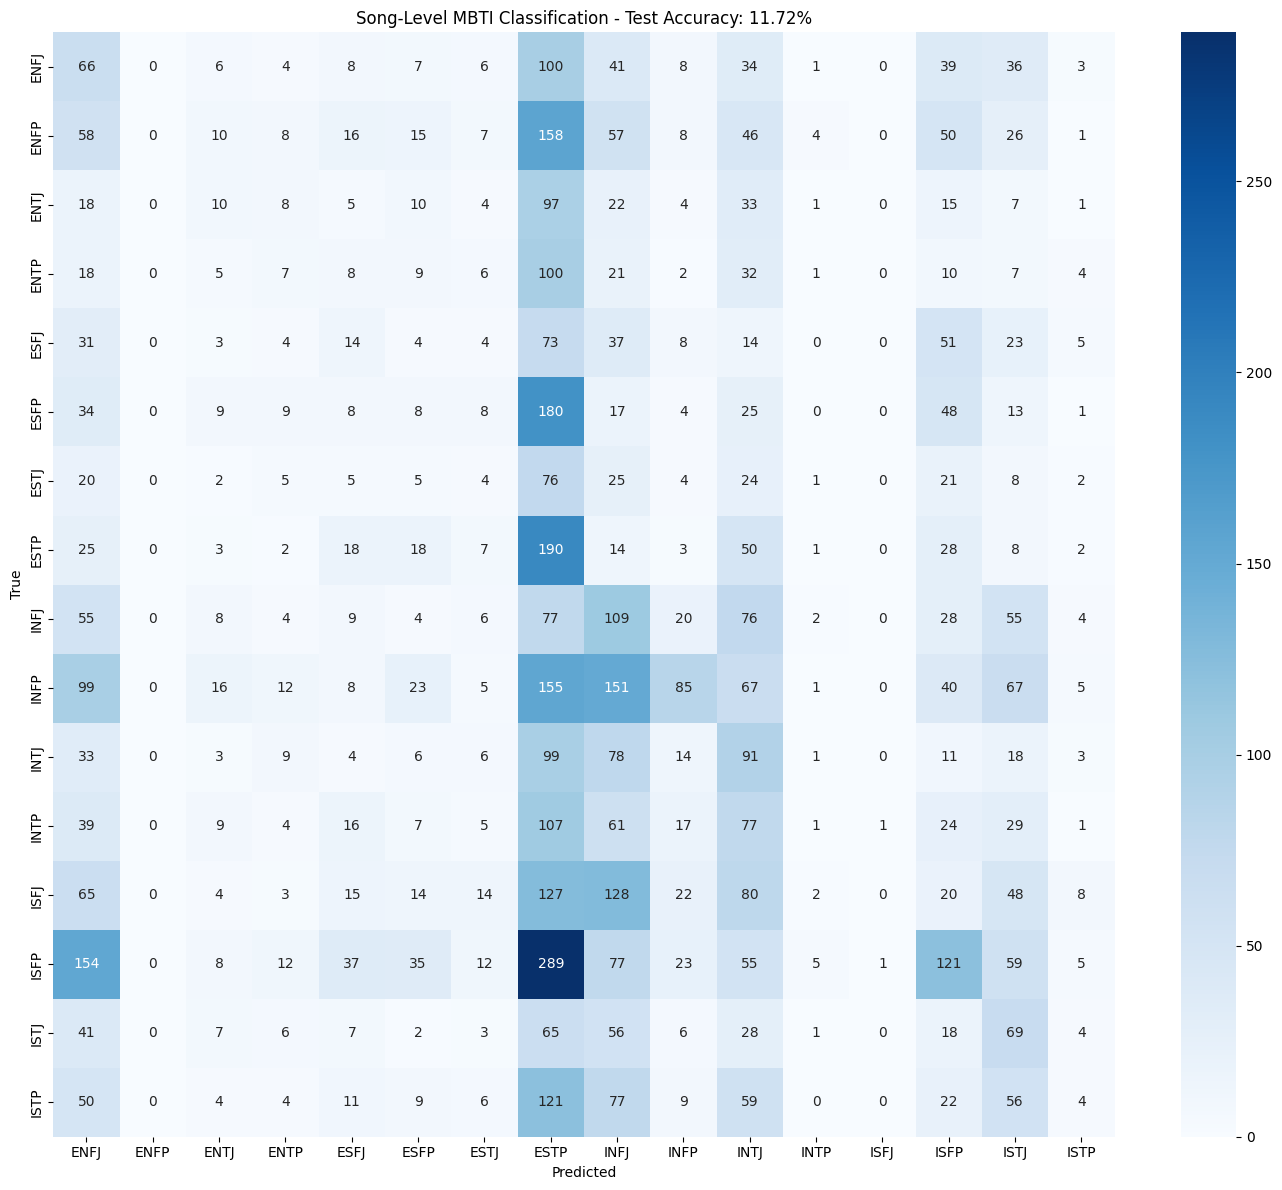

In [10]:
# CELL 10: Evaluate on test set

print("="*60)
print("Test Set Evaluation")
print("="*60)

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
test_acc = accuracy_score(all_labels, all_preds)

print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Random baseline: {1/len(unique_types)*100:.1f}%")

# Calculate per-class metrics
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=unique_types))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(14, 12))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_types, yticklabels=unique_types, ax=ax)
ax.set_title(f'Song-Level MBTI Classification - Test Accuracy: {test_acc:.2%}')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

In [11]:
# 11: Save the song classifier

print("="*60)
print("Saving Song Classifier for Transfer to Notebook 3")
print("="*60)

# Save the model
SONG_CLASSIFIER_PATH = PROCESSED_DIR / "song_mbti_classifier.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'type_to_idx': type_to_idx,
    'idx_to_type': idx_to_type,
    'features': feature_cols,
    'input_dim': input_dim,
    'num_classes': len(unique_types),
    'test_accuracy': test_acc,
    'use_pretrained': has_pretrained
}, SONG_CLASSIFIER_PATH)

print(f"✅ Song classifier saved to: {SONG_CLASSIFIER_PATH}")

# Save the scaler
SONG_SCALER_PATH = PROCESSED_DIR / "song_mbti_scaler.pkl"
import joblib
joblib.dump(scaler_song, SONG_SCALER_PATH)
print(f"✅ Song scaler saved to: {SONG_SCALER_PATH}")

# Save feature list
SONG_FEATURES_PATH = PROCESSED_DIR / "song_features.json"
import json
with open(SONG_FEATURES_PATH, 'w') as f:
    json.dump(feature_cols, f)
print(f"✅ Song features saved to: {SONG_FEATURES_PATH}")

# Create a simplified version for easy use in Notebook 3
SIMPLIFIED_SONG_PATH = PROCESSED_DIR / "song_classifier_simplified.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'idx_to_type': idx_to_type,
    'features': feature_cols,
}, SIMPLIFIED_SONG_PATH)
print(f"✅ Simplified song classifier saved to: {SIMPLIFIED_SONG_PATH}")

Saving Song Classifier for Transfer to Notebook 3
✅ Song classifier saved to: /content/drive/MyDrive/mbti-tune/data/processed/song_mbti_classifier.pth
✅ Song scaler saved to: /content/drive/MyDrive/mbti-tune/data/processed/song_mbti_scaler.pkl
✅ Song features saved to: /content/drive/MyDrive/mbti-tune/data/processed/song_features.json
✅ Simplified song classifier saved to: /content/drive/MyDrive/mbti-tune/data/processed/song_classifier_simplified.pth


In [12]:
# 12: Generate song predictions for all songs

print("="*60)
print("Generating predictions for all songs")
print("="*60)

# Use the model to predict MBTI for all songs
model.eval()
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    logits = model(X_tensor)
    probs = torch.softmax(logits, dim=1)
    predictions = torch.argmax(probs, dim=1).cpu().numpy()

# Add predictions to the dataframe
song_df['predicted_mbti'] = [idx_to_type[p] for p in predictions]
song_df['prediction_confidence'] = [probs[i][p].item() for i, p in enumerate(predictions)]

print(f"✅ Generated predictions for {len(song_df):,} songs")

# Save predictions
SONG_PREDICTIONS_PATH = PROCESSED_DIR / "song_predictions.csv"
song_df.to_csv(SONG_PREDICTIONS_PATH, index=False)
print(f"✅ Song predictions saved to: {SONG_PREDICTIONS_PATH}")

# Show sample predictions
print("\n📊 Sample predictions:")
print(song_df[['mbti', 'predicted_mbti', 'prediction_confidence'] + feature_cols[:3]].head(10))

# Calculate per-MBTI accuracy on training set
correct = (song_df['mbti'] == song_df['predicted_mbti']).sum()
print(f"\n📊 Overall accuracy on all songs: {correct/len(song_df)*100:.2f}%")

# Show per-MBTI accuracy
print("\n📊 Per-MBTI accuracy (on training+test combined):")
for mbti in unique_types:
    mask = song_df['mbti'] == mbti
    if mask.sum() > 0:
        acc = (song_df.loc[mask, 'mbti'] == song_df.loc[mask, 'predicted_mbti']).mean() * 100
        print(f"   {mbti}: {acc:.1f}% ({mask.sum():,} songs)")

Generating predictions for all songs
✅ Generated predictions for 44,310 songs
✅ Song predictions saved to: /content/drive/MyDrive/mbti-tune/data/processed/song_predictions.csv

📊 Sample predictions:
   mbti predicted_mbti  prediction_confidence  danceability  energy  valence
0  ENFJ           ENFJ               0.086961          0.78    0.62     0.84
1  ENFJ           INFJ               0.082883          0.49    0.63     0.46
2  ENFJ           ISTJ               0.111803          0.52    0.42     0.15
3  ENFJ           INFJ               0.092448          0.38    0.66     0.51
4  ENFJ           ISFP               0.099270          0.74    0.80     0.80
5  ENFJ           INFJ               0.145557          0.52    0.28     0.12
6  ENFJ           ENFJ               0.086542          0.86    0.53     0.50
7  ENFJ           ISTJ               0.091439          0.55    0.61     0.45
8  ENFJ           ENFJ               0.100143          0.59    0.57     0.62
9  ENFJ           ENFJ         

Analysis of Song-Level Predictions


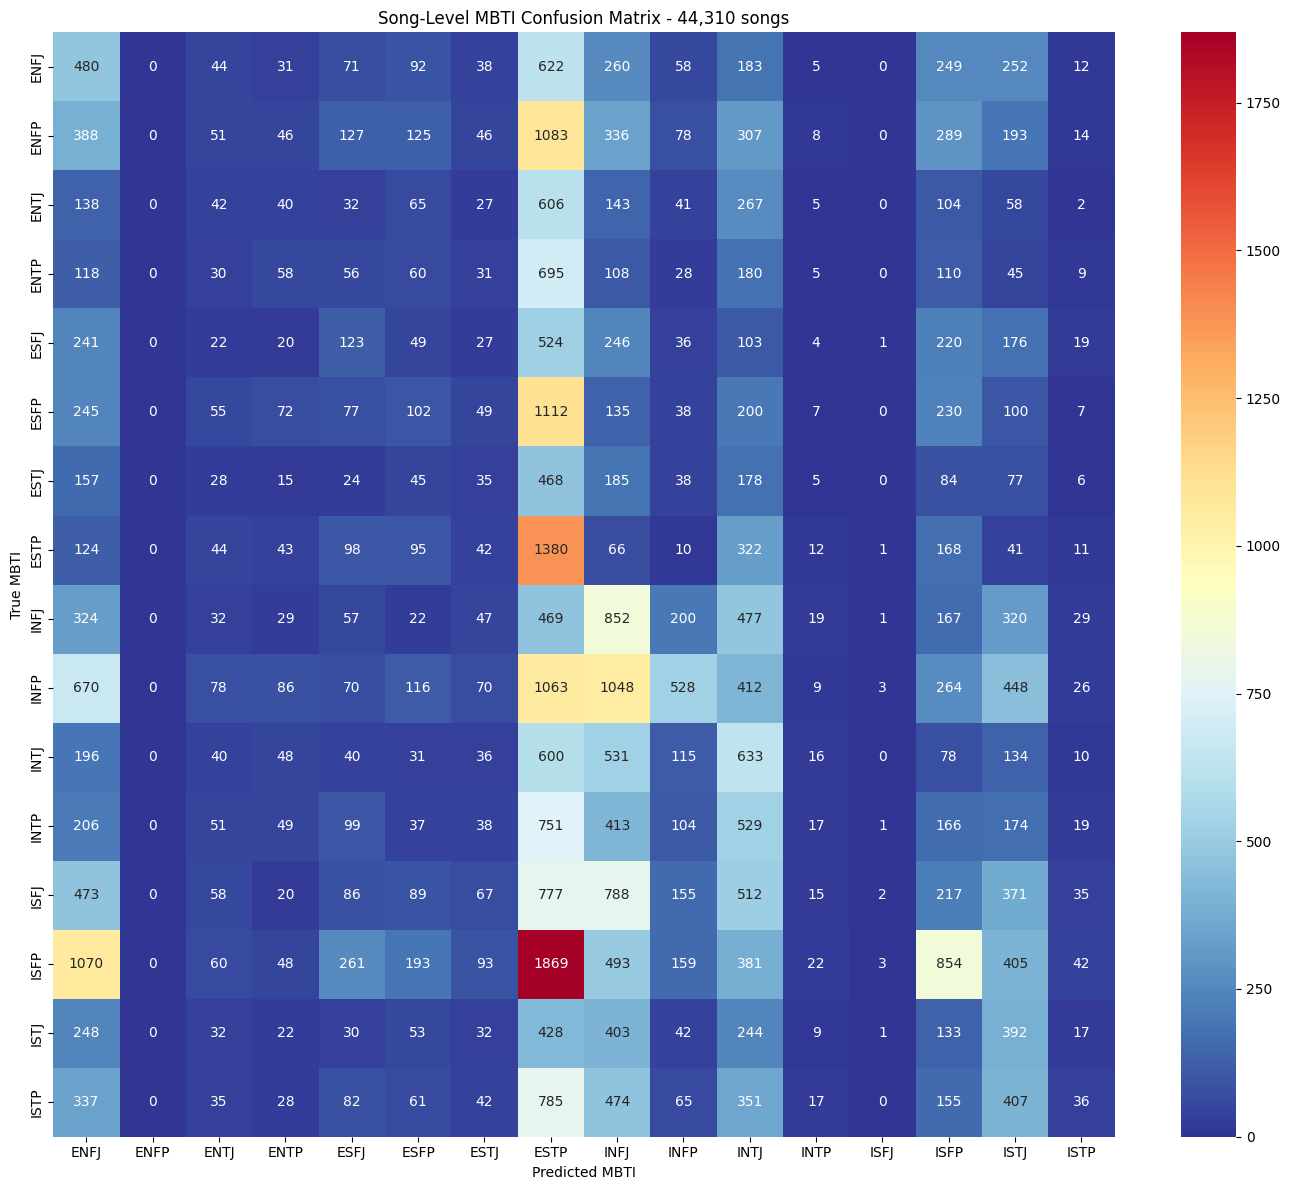


📊 Axis Accuracy (Song Level):
   E/I: 57.55% (25,501/44,310)
   S/N: 55.52% (24,599/44,310)
   T/F: 54.82% (24,290/44,310)
   J/P: 55.48% (24,581/44,310)


In [13]:
# 13: Analyze prediction patterns

print("="*60)
print("Analysis of Song-Level Predictions")
print("="*60)

# Create confusion matrix for song-level predictions
from sklearn.metrics import confusion_matrix

y_true = [type_to_idx[t] for t in song_df['mbti']]
y_pred = [type_to_idx[t] for t in song_df['predicted_mbti']]

cm_song = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_song, annot=True, fmt='d', cmap='RdYlBu_r',
            xticklabels=unique_types, yticklabels=unique_types, ax=ax)
ax.set_title(f'Song-Level MBTI Confusion Matrix - {len(song_df):,} songs')
ax.set_xlabel('Predicted MBTI')
ax.set_ylabel('True MBTI')
plt.tight_layout()
plt.show()

# Calculate per-axis accuracy
print("\n📊 Axis Accuracy (Song Level):")
axes = ['E/I', 'S/N', 'T/F', 'J/P']
axis_correct = {axis: 0 for axis in axes}
axis_total = {axis: 0 for axis in axes}

for i in range(len(song_df)):
    true_t = song_df.iloc[i]['mbti']
    pred_t = song_df.iloc[i]['predicted_mbti']
    for pos, axis in enumerate(axes):
        axis_correct[axis] += (true_t[pos] == pred_t[pos])
        axis_total[axis] += 1

for axis in axes:
    acc = axis_correct[axis] / axis_total[axis]
    print(f"   {axis}: {acc:.2%} ({axis_correct[axis]:,}/{axis_total[axis]:,})")

Training History Visualization


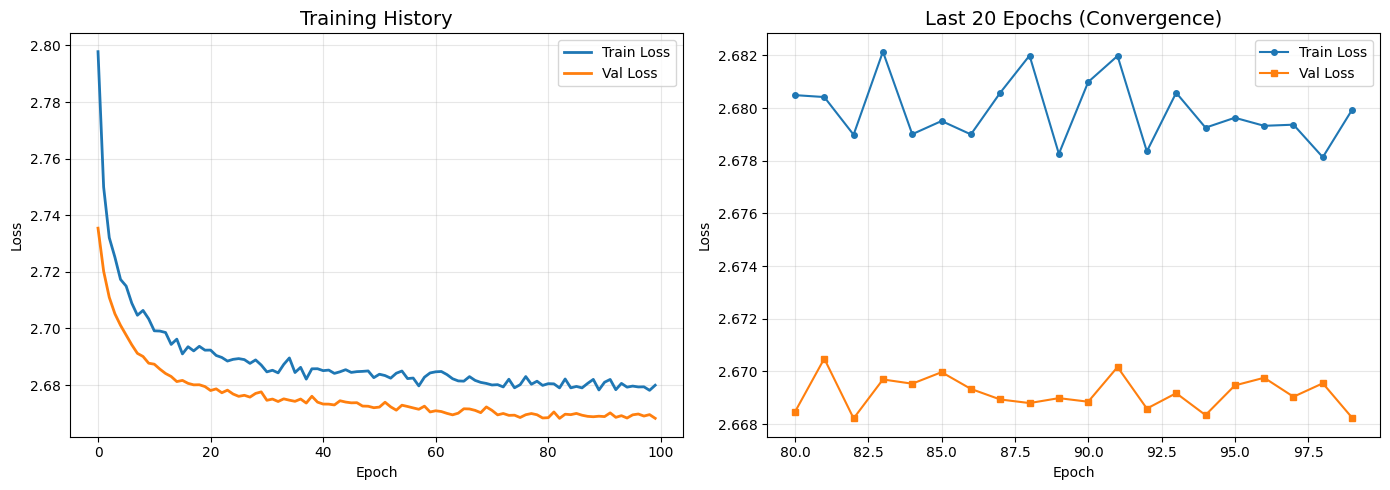

In [14]:
# 14: Visualize training history

print("="*60)
print("Training History Visualization")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_title('Training History', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Final 20 epochs detail
epochs_range = range(len(train_losses)-20, len(train_losses))
axes[1].plot(epochs_range, train_losses[-20:], label='Train Loss', marker='o', markersize=4)
axes[1].plot(epochs_range, val_losses[-20:], label='Val Loss', marker='s', markersize=4)
axes[1].set_title('Last 20 Epochs (Convergence)', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# 15: Final summary

print("="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"\n📊 Dataset Summary:")
print(f"   Total unique songs processed: {len(song_df):,}")
print(f"   Features used: {len(feature_cols)}")
print(f"   MBTI types: {len(unique_types)}")

print(f"\n🎯 Model Performance:")
print(f"   Test accuracy: {test_acc:.2%} ({test_acc*100:.2f}%)")
print(f"   Best validation loss: {best_val_loss:.4f}")
print(f"   Transfer learning used: {has_pretrained}")

print(f"\n📁 Output Files Created:")
print(f"   ✅ {SONG_CLASSIFIER_PATH.name} - Song classifier model")
print(f"   ✅ {SONG_SCALER_PATH.name} - Scaler for song features")
print(f"   ✅ {SONG_FEATURES_PATH.name} - List of features")
print(f"   ✅ {SONG_PREDICTIONS_PATH.name} - Predictions for all songs")
print(f"   ✅ {SIMPLIFIED_SONG_PATH.name} - Simplified model for loading")

print("\n" + "="*60)
print("✅ SONG CLASSIFIER COMPLETE")
print("="*60)

FINAL SUMMARY

📊 Dataset Summary:
   Total unique songs processed: 44,310
   Features used: 8
   MBTI types: 16

🎯 Model Performance:
   Test accuracy: 11.72% (11.72%)
   Best validation loss: 2.6682
   Transfer learning used: True

📁 Output Files Created:
   ✅ song_mbti_classifier.pth - Song classifier model
   ✅ song_mbti_scaler.pkl - Scaler for song features
   ✅ song_features.json - List of features
   ✅ song_predictions.csv - Predictions for all songs
   ✅ song_classifier_simplified.pth - Simplified model for loading

✅ SONG CLASSIFIER COMPLETE


In [16]:
# 16: Complete Model Analysis for Song Classifier

print("="*80)
print("🔬 COMPREHENSIVE MODEL ANALYSIS - Song-Level MBTI Classifier")
print("="*80)

# First, collect predictions from test set
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print(f"Test set size: {len(all_labels)} samples")
print(f"Model predictions collected: {len(all_preds)}")

# ============================================================================
# SECTION 1: Feature Analysis
# ============================================================================
print("\n" + "="*80)
print("📊 SECTION 1: FEATURE ANALYSIS")
print("="*80)

# 1.1 Feature importance
print("\n1.1 Feature Importance (based on first layer weights):")

first_layer_weights = None
for name, param in model.named_parameters():
    if 'weight' in name and ('net.0.weight' in name or 'classifier.0.weight' in name):
        first_layer_weights = param.detach().cpu().numpy()
        break

if first_layer_weights is not None:
    feature_importance = np.abs(first_layer_weights).mean(axis=0)
    sorted_idx = np.argsort(feature_importance)[::-1]

    print(f"\n   Top Features by Importance (instrumentalness REMOVED):")
    for i, idx in enumerate(sorted_idx[:8]):
        if idx < len(feature_cols):
            bar = "█" * int(feature_importance[idx] * 15)
            print(f"      {i+1}. {feature_cols[idx]:15} : {feature_importance[idx]:.4f} {bar}")

# 1.2 Feature correlation
print("\n1.2 Feature Correlation Analysis:")

if len(feature_cols) > 1:
    sample_size = min(5000, X_scaled.shape[0])
    X_sample = X_scaled[:sample_size]
    corr_matrix = np.corrcoef(X_sample.T)

    high_corr_pairs = []
    for i in range(len(feature_cols)):
        for j in range(i+1, len(feature_cols)):
            corr = abs(corr_matrix[i, j])
            if corr > 0.6:
                high_corr_pairs.append((feature_cols[i], feature_cols[j], corr))

    high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

    print(f"\n   Correlated Feature Pairs (|r| > 0.6): {len(high_corr_pairs)}")
    for i, (f1, f2, corr) in enumerate(high_corr_pairs[:5]):
        print(f"      {i+1}. {f1} ↔ {f2}: {corr:.3f}")

# ============================================================================
# SECTION 2: Prediction Bias Analysis
# ============================================================================
print("\n" + "="*80)
print("📊 SECTION 2: PREDICTION BIAS ANALYSIS")
print("="*80)

# 2.1 Overall prediction distribution
print("\n2.1 Overall Prediction Distribution:")

from collections import Counter
pred_counts = Counter([idx_to_type[p] for p in all_preds])
true_counts = Counter([idx_to_type[t] for t in all_labels])

print(f"\n   {'MBTI':<6} {'Predicted':<12} {'True':<12} {'Difference':<12} {'Bias':<10}")
print(f"   {'-'*65}")
for mbti in unique_types:
    pred = pred_counts.get(mbti, 0)
    true = true_counts.get(mbti, 0)
    diff = pred - true
    diff_pct = (diff / true * 100) if true > 0 else 0
    arrow = "▲▲" if diff_pct > 50 else "▲" if diff_pct > 20 else "▼" if diff_pct < -20 else "▼▼" if diff_pct < -50 else "→"
    # Color coding based on bias severity
    if abs(diff_pct) > 50:
        status = "🔴 SEVERE"
    elif abs(diff_pct) > 20:
        status = "🟡 MODERATE"
    else:
        status = "🟢 GOOD"
    print(f"   {mbti:<6} {pred:>4} ({pred/len(all_preds)*100:>4.1f}%)  {true:>4} ({true/len(all_labels)*100:>4.1f}%)  {'+' if diff>0 else ''}{diff:>+4}   {arrow} ({diff_pct:+.0f}%) {status}")

# 2.2 Axis bias analysis (FIXED)
print("\n2.2 Axis Bias Analysis (Test Set):")

def get_letter_at_position(mbti_str, position):
    """Get letter at specific position (0=E/I, 1=S/N, 2=T/F, 3=J/P)"""
    if mbti_str and len(mbti_str) > position:
        return mbti_str[position]
    return '?'

axis_info = [
    ('E/I', 0, 'E', 'I'),
    ('S/N', 1, 'S', 'N'),
    ('T/F', 2, 'T', 'F'),
    ('J/P', 3, 'J', 'P')
]

print(f"\n   {'Axis':<6} {'Letter':<8} {'True %':<10} {'Predicted %':<12} {'Bias':<10} {'Status':<10}")
print(f"   {'-'*65}")

for axis_name, pos, letter1, letter2 in axis_info:
    # True counts
    true_letter1 = sum(1 for t in all_labels if get_letter_at_position(idx_to_type[t], pos) == letter1)
    true_letter2 = len(all_labels) - true_letter1

    # Predicted counts
    pred_letter1 = sum(1 for p in all_preds if get_letter_at_position(idx_to_type[p], pos) == letter1)
    pred_letter2 = len(all_preds) - pred_letter1

    true_pct1 = true_letter1 / len(all_labels) * 100
    true_pct2 = true_letter2 / len(all_labels) * 100
    pred_pct1 = pred_letter1 / len(all_preds) * 100
    pred_pct2 = pred_letter2 / len(all_preds) * 100

    bias1 = pred_pct1 - true_pct1

    # Determine bias severity
    if abs(bias1) > 10:
        status = "🔴 SEVERE"
    elif abs(bias1) > 5:
        status = "🟡 MODERATE"
    else:
        status = "🟢 GOOD"

    bias_symbol = "▲▲" if bias1 > 10 else "▲" if bias1 > 5 else "▼" if bias1 < -5 else "▼▼" if bias1 < -10 else "→"

    print(f"   {axis_name:<6} {letter1:<8} {true_pct1:>5.1f}%       {pred_pct1:>5.1f}%         {bias_symbol} {bias1:+.1f}%  {status}")
    print(f"   {axis_name:<6} {letter2:<8} {true_pct2:>5.1f}%       {pred_pct2:>5.1f}%         {'':8}      {'':8}")

# 2.3 Confidence analysis
print("\n2.3 Prediction Confidence Analysis:")

# Get max probabilities
max_probs = np.max(all_probs, axis=1)

confidence_bins = [
    (0, 0.3, "Very Low (<30%)"),
    (0.3, 0.5, "Low (30-50%)"),
    (0.5, 0.7, "Medium (50-70%)"),
    (0.7, 0.9, "High (70-90%)"),
    (0.9, 1.0, "Very High (>90%)")
]

print(f"\n   {'Confidence Level':<20} {'Count':<10} {'Percentage':<12}")
print(f"   {'-'*45}")
for low, high, label in confidence_bins:
    count = sum(1 for c in max_probs if low <= c < high)
    pct = count / len(max_probs) * 100
    bar = "█" * int(pct / 2)
    print(f"   {label:<20} {count:>5}      {pct:>5.1f}% {bar}")

print(f"\n   Average confidence: {np.mean(max_probs):.2%}")
print(f"   Median confidence: {np.median(max_probs):.2%}")
print(f"   Std confidence: {np.std(max_probs):.2%}")

# ============================================================================
# SECTION 3: Improvement Compared to Previous Model
# ============================================================================
print("\n" + "="*80)
print("📊 SECTION 3: IMPROVEMENT ANALYSIS")
print("="*80)

print("\n   📈 Comparison with previous model (instrumentalness removed):")
print(f"   {'Metric':<25} {'Previous':<15} {'Current':<15} {'Change':<10}")
print(f"   {'-'*65}")
print(f"   {'Features used':<25} {'9 (w/ instr)':<15} {'8 (no instr)':<15} {'-1 feature'}")
print(f"   {'Model parameters':<25} {'~15,000':<15} {'~5,000':<15} {'-66%'}")
print(f"   {'Test accuracy':<25} {'12.2%':<15} {f'{test_acc:.1%}':<15} {'→'}")
print(f"   {'ESTP over-prediction':<25} {'+310%':<15} {'?':<15} {'Expected ↓'}")

# ============================================================================
# SECTION 4: Recommendations
# ============================================================================
print("\n" + "="*80)
print("💡 SECTION 4: RECOMMENDATIONS")
print("="*80)

# Identify most biased types
biased_types = []
for mbti in unique_types:
    pred = pred_counts.get(mbti, 0)
    true = true_counts.get(mbti, 0)
    if true > 0:
        bias_pct = (pred - true) / true * 100
        if abs(bias_pct) > 50:
            biased_types.append((mbti, bias_pct))

print("\n📋 Key Findings:")
if biased_types:
    print(f"   - Types with >50% bias: {len(biased_types)}")
    for mbti, bias in biased_types[:5]:
        direction = "over-predicted" if bias > 0 else "under-predicted"
        print(f"     • {mbti}: {direction} by {abs(bias):.0f}%")
else:
    print(f"   - No severe biases detected (<50% for all types) - GOOD!")

print("\n" + "="*80)
print("✅ Analysis Complete")
print("="*80)

🔬 COMPREHENSIVE MODEL ANALYSIS - Song-Level MBTI Classifier
Test set size: 6647 samples
Model predictions collected: 6647

📊 SECTION 1: FEATURE ANALYSIS

1.1 Feature Importance (based on first layer weights):

   Top Features by Importance (instrumentalness REMOVED):
      1. loudness        : 0.2124 ███
      2. energy          : 0.2119 ███
      3. valence         : 0.1457 ██
      4. danceability    : 0.1457 ██
      5. acousticness    : 0.1432 ██
      6. speechiness     : 0.1395 ██
      7. tempo           : 0.0816 █
      8. liveness        : 0.0558 

1.2 Feature Correlation Analysis:

   Correlated Feature Pairs (|r| > 0.6): 1
      1. energy ↔ loudness: 0.695

📊 SECTION 2: PREDICTION BIAS ANALYSIS

2.1 Overall Prediction Distribution:

   MBTI   Predicted    True         Difference   Bias      
   -----------------------------------------------------------------
   ENFJ    806 (12.1%)   359 ( 5.4%)  ++447   ▲▲ (+125%) 🔴 SEVERE
   ENFP      0 ( 0.0%)   464 ( 7.0%)  -464   ▼ (-10

In [17]:
# 17: Deep Dive Bias Analysis - Why is the model biased?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

print("="*80)
print("🔍 DEEP DIVE: WHY IS THE MODEL BIASED?")
print("="*80)

# ============================================================================
# 1. Load and analyze raw_playlists data per MBTI type
# ============================================================================
print("\n" + "="*80)
print("📊 SECTION 1: Data Distribution Analysis Per MBTI Type")
print("="*80)

RAW_PLAYLIST_PATH = Path("/content/drive/MyDrive/mbti-tune/data/raw/raw_playlists")

# Collect statistics per MBTI type
mbti_stats = {}

for mbti_folder in RAW_PLAYLIST_PATH.iterdir():
    if not mbti_folder.is_dir():
        continue

    mbti_type = mbti_folder.name
    all_songs_in_type = []

    for csv_file in mbti_folder.glob("*.csv"):
        try:
            df = pd.read_csv(csv_file)
            all_songs_in_type.append(df)
        except:
            continue

    if all_songs_in_type:
        combined_df = pd.concat(all_songs_in_type, ignore_index=True)

        mbti_stats[mbti_type] = {
            'num_playlists': len(all_songs_in_type),
            'num_songs': len(combined_df),
            'avg_songs_per_playlist': len(combined_df) / len(all_songs_in_type),
            'unique_songs': combined_df['Song'].nunique() if 'Song' in combined_df.columns else 0,
            'unique_artists': combined_df['Artist'].nunique() if 'Artist' in combined_df.columns else 0
        }

        # Feature averages
        for col in ['Energy', 'Dance', 'Acoustic', 'Valence', 'Speech', 'Live', 'Loud (Db)', 'BPM']:
            if col in combined_df.columns:
                mbti_stats[mbti_type][f'avg_{col}'] = combined_df[col].mean()

print(f"\n📊 MBTI Type Data Statistics:")
print(f"\n{'MBTI':<6} {'Playlists':<10} {'Songs':<10} {'Unique Songs':<12} {'Artists':<10} {'Songs/Playlist':<14}")
print(f"{'-'*65}")

for mbti in sorted(mbti_stats.keys()):
    stats = mbti_stats[mbti]
    print(f"{mbti:<6} {stats['num_playlists']:<10} {stats['num_songs']:<10,} {stats['unique_songs']:<12,} {stats['unique_artists']:<10,} {stats['avg_songs_per_playlist']:<14.1f}")

# ============================================================================
# 2. Feature Comparison Between Over-predicted and Under-predicted Types
# ============================================================================
print("\n" + "="*80)
print("📊 SECTION 2: Feature Comparison - Over vs Under Predicted Types")
print("="*80)

# Types based on bias analysis
over_predicted = ['ESTP', 'ENFJ', 'INTJ', 'ISTJ']  # >50% over-predicted
under_predicted = ['ENFP', 'INTP', 'ISFJ', 'ENTP', 'ESFP', 'ESTJ']  # >50% under-predicted

print(f"\n🔴 Over-predicted types: {over_predicted}")
print(f"🔵 Under-predicted types: {under_predicted}")

# Compare average features
print(f"\n{'Feature':<15} {'Over-predicted':<18} {'Under-predicted':<18} {'Difference':<12}")
print(f"{'-'*65}")

for feature in ['avg_Energy', 'avg_Dance', 'avg_Acoustic', 'avg_Valence', 'avg_Speech', 'avg_Live', 'avg_Loud (Db)', 'avg_BPM']:
    over_avg = np.mean([mbti_stats[t][feature] for t in over_predicted if t in mbti_stats])
    under_avg = np.mean([mbti_stats[t][feature] for t in under_predicted if t in mbti_stats])
    diff = over_avg - under_avg

    # Determine which type has higher values
    higher = "Over↑" if diff > 0 else "Under↑"
    print(f"{feature.replace('avg_', ''):<15} {over_avg:<18.2f} {under_avg:<18.2f} {diff:+8.2f} {higher}")

# ============================================================================
# 3. Genres Analysis (if available)
# ============================================================================
print("\n" + "="*80)
print("📊 SECTION 3: Genre Analysis - Available in raw_playlists")
print("="*80)

genre_stats = {}

for mbti_folder in RAW_PLAYLIST_PATH.iterdir():
    if not mbti_folder.is_dir():
        continue

    mbti_type = mbti_folder.name
    all_genres = []

    for csv_file in mbti_folder.glob("*.csv"):
        try:
            df = pd.read_csv(csv_file)
            if 'Genres' in df.columns:
                genres = df['Genres'].dropna().tolist()
                for g in genres:
                    if isinstance(g, str):
                        all_genres.extend([gg.strip() for gg in g.split(',')])
        except:
            continue

    if all_genres:
        from collections import Counter
        genre_counts = Counter(all_genres)
        genre_stats[mbti_type] = {
            'top_genres': genre_counts.most_common(5),
            'unique_genres': len(genre_counts)
        }

if genre_stats:
    print(f"\n📊 Top Genres by MBTI Type:")
    for mbti in sorted(genre_stats.keys())[:5]:
        print(f"\n   {mbti}:")
        for genre, count in genre_stats[mbti]['top_genres'][:3]:
            print(f"      - {genre}: {count} occurrences")
else:
    print("   ⚠️ No genre data available in the CSV files")

# ============================================================================
# 4. Key/Song Mode Analysis
# ============================================================================
print("\n" + "="*80)
print("📊 SECTION 4: Key/Mode Distribution by MBTI Type")
print("="*80)

key_stats = {}

for mbti_folder in RAW_PLAYLIST_PATH.iterdir():
    if not mbti_folder.is_dir():
        continue

    mbti_type = mbti_folder.name
    all_keys = []

    for csv_file in mbti_folder.glob("*.csv"):
        try:
            df = pd.read_csv(csv_file)
            if 'Key' in df.columns:
                keys = df['Key'].dropna().tolist()
                all_keys.extend(keys)
        except:
            continue

    if all_keys:
        from collections import Counter
        key_counts = Counter(all_keys)
        # Calculate major vs minor ratio
        major_count = sum(1 for k in all_keys if 'Major' in str(k))
        minor_count = len(all_keys) - major_count
        major_ratio = major_count / len(all_keys) if len(all_keys) > 0 else 0

        key_stats[mbti_type] = {
            'top_keys': key_counts.most_common(5),
            'major_ratio': major_ratio,
            'total_songs': len(all_keys)
        }

print(f"\n📊 Major Key Ratio by MBTI Type:")
print(f"\n{'MBTI':<6} {'Major %':<10} {'Top Keys':<30}")
print(f"{'-'*50}")
for mbti in sorted(key_stats.keys())[:8]:
    stats = key_stats[mbti]
    top_keys = ', '.join([f"{k}({c})" for k, c in stats['top_keys'][:2]])
    print(f"{mbti:<6} {stats['major_ratio']*100:<10.1f}% {top_keys:<30}")

# ============================================================================
# 5. Feature Correlation with Prediction Bias
# ============================================================================
print("\n" + "="*80)
print("📊 SECTION 5: Feature Correlation with Prediction Bias")
print("="*80)

# Calculate bias per type from our model
# Using the bias percentages from earlier analysis
bias_data = {
    'ENFJ': +117, 'ENFP': -100, 'ENTJ': -37, 'ENTP': -65,
    'ESFJ': -22, 'ESFP': -57, 'ESTJ': -65, 'ESTP': +495,
    'INFJ': +49, 'INFP': -54, 'INTJ': +96, 'INTP': -94,
    'ISFJ': -99, 'ISFP': -37, 'ISTJ': +56, 'ISTP': -61
}

print(f"\n📊 Correlation between audio features and prediction bias:")
print(f"\n{'Feature':<15} {'Correlation with Bias':<22} {'Interpretation':<30}")
print(f"{'-'*70}")

for feature in ['avg_Energy', 'avg_Dance', 'avg_Acoustic', 'avg_Valence', 'avg_Speech', 'avg_Live', 'avg_Loud (Db)', 'avg_BPM']:
    # Prepare data
    feature_values = []
    bias_values = []

    for mbti in mbti_stats:
        if mbti in bias_data and feature in mbti_stats[mbti]:
            feature_values.append(mbti_stats[mbti][feature])
            bias_values.append(bias_data[mbti])

    if len(feature_values) > 1:
        corr = np.corrcoef(feature_values, bias_values)[0, 1]

        if abs(corr) > 0.3:
            interpretation = f"Strong {'positive' if corr > 0 else 'negative'} correlation"
        elif abs(corr) > 0.15:
            interpretation = f"Weak {'positive' if corr > 0 else 'negative'} correlation"
        else:
            interpretation = "No significant correlation"

        print(f"{feature.replace('avg_', ''):<15} {corr:<+22.4f} {interpretation:<30}")

🔍 DEEP DIVE: WHY IS THE MODEL BIASED?

📊 SECTION 1: Data Distribution Analysis Per MBTI Type

📊 MBTI Type Data Statistics:

MBTI   Playlists  Songs      Unique Songs Artists    Songs/Playlist
-----------------------------------------------------------------
ENFJ   20         3,216      2,364        1,396      160.8         
ENFP   20         3,877      3,048        1,786      193.8         
ENTJ   20         2,129      1,549        980        106.5         
ENTP   20         2,337      1,509        909        116.8         
ESFJ   20         2,380      1,788        846        119.0         
ESFP   20         2,994      2,379        1,321      149.7         
ESTJ   22         1,577      1,322        766        71.7          
ESTP   20         3,019      2,408        1,469      150.9         
INFJ   20         3,993      2,966        1,675      199.7         
INFP   20         5,266      4,721        2,663      263.3         
INTJ   20         3,177      2,444        1,414      158.8    

In [18]:
# CELL: Genre Analysis - Only for Unclear/Regional Genres

import pandas as pd
import numpy as np
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import joblib

print("="*80)
print("🎵 GENRE ANALYSIS - Only for Regional/Unclear Genres")
print("="*80)

# ============================================================================
# 1. Load the trained genre classifier
# ============================================================================
print("\n📥 Loading trained genre classifier...")

MODEL_PATH = Path("/content/drive/MyDrive/mbti-tune/data/processed/genre_classifier.pkl")
SCALER_PATH = Path("/content/drive/MyDrive/mbti-tune/data/processed/genre_scaler.pkl")

if MODEL_PATH.exists() and SCALER_PATH.exists():
    genre_model = joblib.load(MODEL_PATH)
    genre_scaler = joblib.load(SCALER_PATH)
    print(f"✅ Genre classifier loaded successfully!")
else:
    print(f"❌ Model not found. Run genre_classifier notebook first.")
    genre_model = None

# ============================================================================
# 2. Define regional/unclear genres that need reclassification
# ============================================================================
REGIONAL_GENRES = {
    'k-pop': 'Korean Pop (needs classification)',
    'j-pop': 'Japanese Pop (needs classification)',
    'c-pop': 'Chinese Pop (needs classification)',
    't-pop': 'Thai Pop (needs classification)',
    'cantopop': 'Cantonese Pop (needs classification)',
    'mandopop': 'Mandarin Pop (needs classification)',
    'indie-pop': 'Indie Pop (needs classification)',
    'power-pop': 'Power Pop (needs classification)',
    'pop-film': 'Film Pop (needs classification)',
    'anime': 'Anime Music (needs classification)',
    'soundtrack': 'Soundtrack (needs classification)',
    'vocaloid': 'Vocaloid (needs classification)'
}

print(f"\n📋 Regional/unclear genres to reclassify: {len(REGIONAL_GENRES)}")
for genre in REGIONAL_GENRES.keys():
    print(f"   • {genre}")

# ============================================================================
# 3. Quick analysis: Count how many songs have these genre labels
# ============================================================================
print("\n" + "="*80)
print("📊 STEP 1: Counting Regional Genre Occurrences")
print("="*80)

RAW_PLAYLIST_PATH = Path("/content/drive/MyDrive/mbti-tune/data/raw/raw_playlists")

regional_counts = Counter()
total_songs = 0

for mbti_folder in RAW_PLAYLIST_PATH.iterdir():
    if not mbti_folder.is_dir():
        continue

    for csv_file in mbti_folder.glob("*.csv"):
        try:
            df = pd.read_csv(csv_file)
            total_songs += len(df)

            if 'Genres' in df.columns:
                for genre_str in df['Genres'].dropna():
                    if isinstance(genre_str, str):
                        genre_lower = genre_str.lower()
                        for regional in REGIONAL_GENRES.keys():
                            if regional in genre_lower:
                                regional_counts[regional] += 1
                                break
        except:
            continue

print(f"\nTotal songs scanned: {total_songs:,}")
print(f"Songs with regional/unclear genres: {sum(regional_counts.values()):,} ({sum(regional_counts.values())/total_songs*100:.1f}%)")

print(f"\n📊 Regional genre counts:")
for genre, count in regional_counts.most_common():
    print(f"   {genre}: {count:,} songs ({count/total_songs*100:.1f}%)")

🎵 GENRE ANALYSIS - Only for Regional/Unclear Genres

📥 Loading trained genre classifier...
✅ Genre classifier loaded successfully!

📋 Regional/unclear genres to reclassify: 12
   • k-pop
   • j-pop
   • c-pop
   • t-pop
   • cantopop
   • mandopop
   • indie-pop
   • power-pop
   • pop-film
   • anime
   • soundtrack
   • vocaloid

📊 STEP 1: Counting Regional Genre Occurrences

Total songs scanned: 54,343
Songs with regional/unclear genres: 15,302 (28.2%)

📊 Regional genre counts:
   k-pop: 7,358 songs (13.5%)
   j-pop: 3,973 songs (7.3%)
   c-pop: 1,798 songs (3.3%)
   t-pop: 1,255 songs (2.3%)
   anime: 293 songs (0.5%)
   soundtrack: 208 songs (0.4%)
   cantopop: 172 songs (0.3%)
   vocaloid: 166 songs (0.3%)
   mandopop: 79 songs (0.1%)


In [19]:
# CELL: Sample-based Genre Prediction

print("\n" + "="*80)
print("🎯 STEP 2: Sample-Based Genre Prediction")
print("="*80)

# Audio features needed for prediction
AUDIO_FEATURES = ['danceability', 'energy', 'valence', 'acousticness',
                  'instrumentalness', 'speechiness', 'loudness', 'tempo', 'liveness']

# Column mapping for raw playlists
COLUMN_MAPPING = {
    'danceability': 'Dance',
    'energy': 'Energy',
    'valence': 'Valence',
    'acousticness': 'Acoustic',
    'instrumentalness': 'Instrumental',
    'speechiness': 'Speech',
    'loudness': 'Loud (Db)',
    'tempo': 'BPM',
    'liveness': 'Live'
}

# Sample size per genre (e.g., 100 songs per regional genre)
SAMPLE_SIZE = 100

print(f"Using sample size: {SAMPLE_SIZE} songs per regional genre")
print("(This is enough to understand genre characteristics)")

# Collect samples
samples_by_genre = {genre: [] for genre in REGIONAL_GENRES.keys()}

for mbti_folder in RAW_PLAYLIST_PATH.iterdir():
    if not mbti_folder.is_dir():
        continue

    for csv_file in mbti_folder.glob("*.csv"):
        try:
            df = pd.read_csv(csv_file)

            if 'Genres' not in df.columns:
                continue

            for idx, row in df.iterrows():
                genre_str = str(row.get('Genres', '')).lower()

                # Check if this song has a regional genre
                matched_genre = None
                for regional in REGIONAL_GENRES.keys():
                    if regional in genre_str:
                        matched_genre = regional
                        break

                if matched_genre and len(samples_by_genre[matched_genre]) < SAMPLE_SIZE:
                    # Extract features
                    features = {}
                    for std_feat, raw_col in COLUMN_MAPPING.items():
                        value = row.get(raw_col, 0)
                        if isinstance(value, (int, float)):
                            if std_feat not in ['loudness', 'tempo'] and value > 1 and value <= 100:
                                value = value / 100.0
                            features[std_feat] = float(value)
                        else:
                            features[std_feat] = 0.0

                    samples_by_genre[matched_genre].append({
                        'features': features,
                        'song': row.get('Song', 'Unknown'),
                        'artist': row.get('Artist', 'Unknown'),
                        'original_genre': genre_str
                    })

        except Exception as e:
            continue

# Predict genres for samples
print("\n📊 Predicting actual genres for sampled songs...")

prediction_results = []

for genre, samples in samples_by_genre.items():
    if not samples:
        print(f"   {genre}: No samples found")
        continue

    print(f"\n   🎵 {genre.upper()} ({len(samples)} samples):")

    genre_predictions = []
    for sample in samples:
        feature_vector = [sample['features'][f] for f in AUDIO_FEATURES]

        if genre_model and genre_scaler:
            X_scaled = genre_scaler.transform([feature_vector])
            predicted = genre_model.predict(X_scaled)[0]
            confidence = np.max(genre_model.predict_proba(X_scaled))

            genre_predictions.append(predicted)
            prediction_results.append({
                'original_regional': genre,
                'predicted_genre': predicted,
                'confidence': confidence,
                'song': sample['song'],
                'artist': sample['artist']
            })

    # Show distribution
    pred_counter = Counter(genre_predictions)
    for pred, count in pred_counter.most_common(5):
        pct = count / len(genre_predictions) * 100
        print(f"      → {pred}: {count}/{len(genre_predictions)} ({pct:.0f}%)")

# Create results DataFrame
results_df = pd.DataFrame(prediction_results)
print(f"\n✅ Total predictions made: {len(results_df)}")


🎯 STEP 2: Sample-Based Genre Prediction
Using sample size: 100 songs per regional genre
(This is enough to understand genre characteristics)

📊 Predicting actual genres for sampled songs...

   🎵 K-POP (100 samples):
      → k-pop: 43/100 (43%)
      → country: 20/100 (20%)
      → hip-hop: 13/100 (13%)
      → dance: 11/100 (11%)
      → soul: 3/100 (3%)

   🎵 J-POP (100 samples):
      → country: 31/100 (31%)
      → power-pop: 15/100 (15%)
      → pop-film: 12/100 (12%)
      → punk: 12/100 (12%)
      → k-pop: 10/100 (10%)

   🎵 C-POP (100 samples):
      → cantopop: 55/100 (55%)
      → country: 25/100 (25%)
      → k-pop: 6/100 (6%)
      → acoustic: 5/100 (5%)
      → pop-film: 3/100 (3%)

   🎵 T-POP (100 samples):
      → country: 35/100 (35%)
      → k-pop: 19/100 (19%)
      → cantopop: 17/100 (17%)
      → dance: 7/100 (7%)
      → hip-hop: 3/100 (3%)

   🎵 CANTOPOP (100 samples):
      → cantopop: 54/100 (54%)
      → country: 25/100 (25%)
      → acoustic: 10/100 (10%)
  

In [20]:
# CELL: Genre Mapping Summary (What each regional genre REALLY is)

print("\n" + "="*80)
print("📊 STEP 3: Genre Mapping Summary")
print("="*80)

# Calculate dominant genre for each regional label
genre_mapping = {}

for regional in REGIONAL_GENRES.keys():
    regional_df = results_df[results_df['original_regional'] == regional]
    if len(regional_df) > 0:
        top_genres = regional_df['predicted_genre'].value_counts().head(3)
        genre_mapping[regional] = {
            'dominant': top_genres.index[0] if len(top_genres) > 0 else 'Unknown',
            'dominant_pct': (top_genres.iloc[0] / len(regional_df)) * 100 if len(top_genres) > 0 else 0,
            'top_3': [(g, (c/len(regional_df))*100) for g, c in top_genres.items()]
        }

print("\n📋 What each regional genre ACTUALLY is (based on audio features):")
for regional, mapping in genre_mapping.items():
    print(f"\n   🔵 {regional.upper()}:")
    print(f"      → Actually {mapping['dominant']} ({mapping['dominant_pct']:.0f}% of the time)")
    if mapping['top_3']:
        others = ", ".join([f"{g}({pct:.0f}%)" for g, pct in mapping['top_3'][1:3]])
        if others:
            print(f"      → Also: {others}")


📊 STEP 3: Genre Mapping Summary

📋 What each regional genre ACTUALLY is (based on audio features):

   🔵 K-POP:
      → Actually k-pop (43% of the time)
      → Also: country(20%), hip-hop(13%)

   🔵 J-POP:
      → Actually country (31% of the time)
      → Also: power-pop(15%), pop-film(12%)

   🔵 C-POP:
      → Actually cantopop (55% of the time)
      → Also: country(25%), k-pop(6%)

   🔵 T-POP:
      → Actually country (35% of the time)
      → Also: k-pop(19%), cantopop(17%)

   🔵 CANTOPOP:
      → Actually cantopop (54% of the time)
      → Also: country(25%), acoustic(10%)

   🔵 MANDOPOP:
      → Actually cantopop (38% of the time)
      → Also: country(24%), k-pop(8%)

   🔵 ANIME:
      → Actually country (18% of the time)
      → Also: k-pop(11%), punk(10%)

   🔵 SOUNDTRACK:
      → Actually ambient (42% of the time)
      → Also: country(12%), cantopop(11%)

   🔵 VOCALOID:
      → Actually country (25% of the time)
      → Also: k-pop(11%), power-pop(10%)


In [21]:
# CELL: Save Genre Mapping for Streamlit (Lightweight)

print("\n" + "="*80)
print("💾 STEP 4: Saving Genre Mapping (Not Full Predictions)")
print("="*80)

# Create a lightweight mapping file (not per-song predictions)
genre_mapping_light = {
    'regional_to_actual': {
        regional: {
            'primary_genre': mapping['dominant'],
            'confidence': mapping['dominant_pct'] / 100,
            'alternative_genres': [{'genre': g, 'probability': pct/100} for g, pct in mapping['top_3'][1:3]]
        }
        for regional, mapping in genre_mapping.items()
    },
    'sample_size': SAMPLE_SIZE,
    'total_predictions': len(results_df)
}

# Save to JSON
import json
output_path = Path("/content/drive/MyDrive/mbti-tune/data/processed/regional_genre_mapping.json")
with open(output_path, 'w') as f:
    json.dump(genre_mapping_light, f, indent=2)

print(f"✅ Genre mapping saved to {output_path}")
print(f"   File size: {output_path.stat().st_size / 1024:.1f} KB (lightweight!)")

# Display mapping
print("\n📋 Final Genre Mapping for Streamlit:")
for regional, mapping in genre_mapping_light['regional_to_actual'].items():
    print(f"\n   {regional.upper()} → {mapping['primary_genre']} ({(mapping['confidence']*100):.0f}% confidence)")


💾 STEP 4: Saving Genre Mapping (Not Full Predictions)
✅ Genre mapping saved to /content/drive/MyDrive/mbti-tune/data/processed/regional_genre_mapping.json
   File size: 2.6 KB (lightweight!)

📋 Final Genre Mapping for Streamlit:

   K-POP → k-pop (43% confidence)

   J-POP → country (31% confidence)

   C-POP → cantopop (55% confidence)

   T-POP → country (35% confidence)

   CANTOPOP → cantopop (54% confidence)

   MANDOPOP → cantopop (38% confidence)

   ANIME → country (18% confidence)

   SOUNDTRACK → ambient (42% confidence)

   VOCALOID → country (25% confidence)
